# Hindustani Vocal Transcription — Multi-Raga Demo

This notebook demonstrates the full transcription pipeline from Jain & Arthur (2023) DLfM,
extended with **adaptive windowing**, evaluated across **all 11 OHV-annotated ragas**
using the Saraga 1.5 Hindustani dataset.

Run all cells top-to-bottom after completing `conda env create -f environment.yml && pip install -e .`

In [24]:
# Cell 0 — Setup, Imports & OHV→Saraga Mapping
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style="whitegrid", font_scale=1.1)

ROOT = Path("..") if Path("../configs").exists() else Path(".")
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))

from hcm_transcription.preprocessing import TonicNormalizer
from hcm_transcription.segmentation import (
    StaticWindower, AdaptiveWindower, segment_phrases,
)
from hcm_transcription.ornamentation import OrnamentClassifier, LabelMapper
from hcm_transcription.evaluation import (
    weighted_normalized_levenshtein, evaluate_file,
    boundary_hit_rate, ornament_classification_report,
)
from hcm_transcription.utils import load_config, load_raga_dict
from data.loaders.saraga_loader import SaragaHindustaniLoader
from data.loaders.ohv_loader import OHVLoader

cfg = load_config(str(ROOT / "configs" / "default.yaml"))
raga_dict = load_raga_dict(str(ROOT / "data" / "raga_dict.json"))

# ── OHV → Saraga 1.5 mapping ─────────────────────────────────────────
# Each OHV track_id maps to (album, track_folder, raga_dict_key).
# 14 OHV files cover 11 unique audio renditions (3 have duplicate annotations).
SARAGA15_ROOT = (ROOT / ".." / "saraga1.5_hindustani").resolve()
OHV_PATH = (ROOT / cfg["data"]["ohv_data_path"]).resolve()

OHV_SARAGA_MAP = {
    "AahirBhairon_av": ("Geetinandan : Part-3 by Ajoy Chakrabarty", "Aahir Bhairon", "ahir_bhairon"),
    "Bairagi_rj": ("Geetinandan : Part-3 by Ajoy Chakrabarty", "Bairagi", "bairagi"),
    "BhairaviDadr_av": ("Raag Bihag & Bhairavi Dadra by Omkar Dadarkar", "Bhairavi Dadra", "bhairavi_dadra"),
    "Irani Bhairavi Thumri_sb": ("New Signature by Brajeshwar Mukherjee", "Irani Bhairavi Thumri", "irani_bhairavi"),
    "IraniBhairaviThumri_av": ("New Signature by Brajeshwar Mukherjee", "Irani Bhairavi Thumri", "irani_bhairavi"),
    "Kalavati_vi": ("Geetinandan : Part-3 by Ajoy Chakrabarty", "Kalavati", "kalavati"),
    "Malkauns_sb": ("Raag Malkauns, Chandrakauns & Majh Khamaj Thumri by Satyasheel Deshpande", "Raag Malkauns", "malkauns"),
    "malkauns_vh": ("Raag Malkauns, Chandrakauns & Majh Khamaj Thumri by Satyasheel Deshpande", "Raag Malkauns", "malkauns"),
    "manjkhamaj_vh": ("Raag Malkauns, Chandrakauns & Majh Khamaj Thumri by Satyasheel Deshpande", "Majh Khamaj Thumri", "majh_khamaj_thumri"),
    "natbhairon_vh": ("Geetinandan : Part-3 by Ajoy Chakrabarty", "Nat Bhairon", "nat_bhairav"),
    "Raag Chandrakauns_SnehaBhat": ("Raag Malkauns, Chandrakauns & Majh Khamaj Thumri by Satyasheel Deshpande", "Raag Chandrakauns", "chandrakauns"),
    "RaagChandrakauns_av": ("Raag Malkauns, Chandrakauns & Majh Khamaj Thumri by Satyasheel Deshpande", "Raag Chandrakauns", "chandrakauns"),
    "raageshree_vh": ("Geetinandan : Part-3 by Ajoy Chakrabarty", "Raageshree", "raageshree"),
    "todi_dp": ("Geetinandan : Part-3 by Ajoy Chakrabarty", "Todi", "todi"),
}

print(f"Config loaded. Ragas in dict: {len(raga_dict['ragas'])}")
print(f"OHV tracks: {len(OHV_SARAGA_MAP)} annotations across 11 renditions")
print(f"Saraga 1.5 root: {SARAGA15_ROOT}")

Config loaded. Ragas in dict: 37
OHV tracks: 14 annotations across 11 renditions
Saraga 1.5 root: /Users/yalu/automated-symbolic-transcription-hindustani-vocals/saraga1.5_hindustani


In [25]:
# Cell 1 — Load all Saraga tracks for OHV renditions
# Each unique (album, track) pair is loaded once via SaragaHindustaniLoader.

loaded_tracks = {}  # (album, track_name) → SaragaTrack
for ohv_id, (album, track_name, raga_key) in OHV_SARAGA_MAP.items():
    key = (album, track_name)
    if key in loaded_tracks:
        continue
    album_dir = SARAGA15_ROOT / album
    loader = SaragaHindustaniLoader(data_home=str(album_dir))
    trk = loader.load_track(track_name)
    # Override raga with our known raga_dict key (metadata may differ)
    trk.raga = raga_key
    loaded_tracks[key] = trk
    print(f"  Loaded {track_name:30s} | {trk.raga:20s} | tonic={trk.tonic:.2f} Hz | "
          f"{trk.f0_times[-1]:.0f}s | {len(trk.f0_freqs):,} samples "
          f"| phrases={len(trk.phrases) if trk.phrases else 0}")

print(f"\n{len(loaded_tracks)} unique Saraga tracks loaded for 11 renditions.")

  Loaded Aahir Bhairon                  | ahir_bhairon         | tonic=138.59 Hz | 589s | 132,505 samples | phrases=24
  Loaded Bairagi                        | bairagi              | tonic=138.59 Hz | 899s | 202,201 samples | phrases=45
  Loaded Bhairavi Dadra                 | bhairavi_dadra       | tonic=155.56 Hz | 602s | 135,350 samples | phrases=7
  Loaded Irani Bhairavi Thumri          | irani_bhairavi       | tonic=196.00 Hz | 360s | 81,071 samples | phrases=4
  Loaded Kalavati                       | kalavati             | tonic=138.59 Hz | 344s | 77,309 samples | phrases=18
  Loaded Raag Malkauns                  | malkauns             | tonic=141.01 Hz | 2287s | 514,516 samples | phrases=50
  Loaded Majh Khamaj Thumri             | majh_khamaj_thumri   | tonic=141.01 Hz | 319s | 71,790 samples | phrases=23
  Loaded Nat Bhairon                    | nat_bhairav          | tonic=138.59 Hz | 638s | 143,502 samples | phrases=34
  Loaded Raag Chandrakauns              | chandrakau

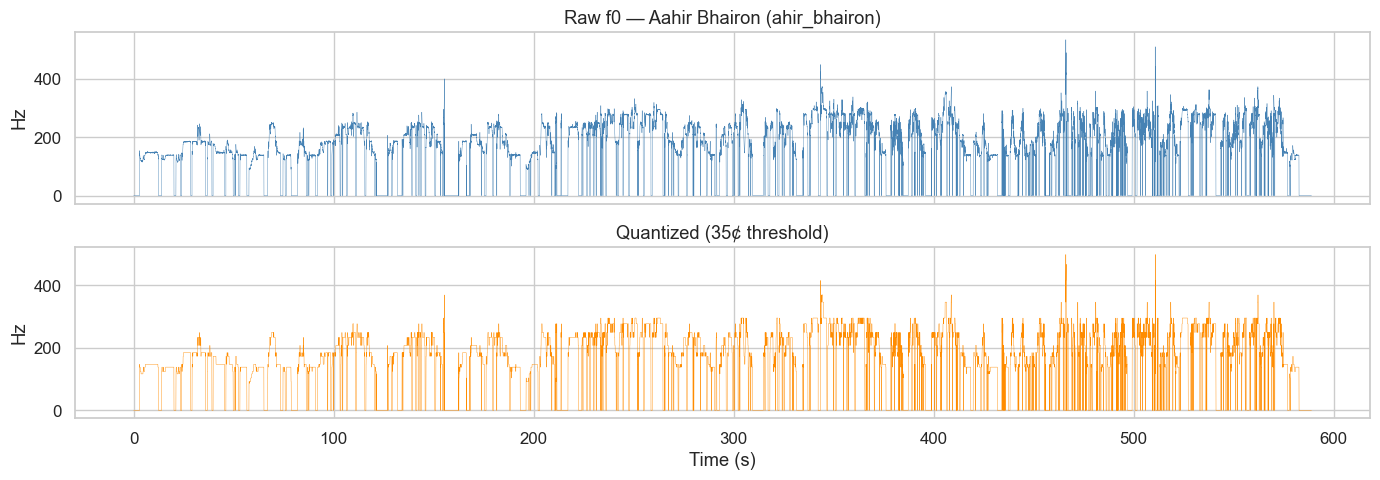


Preprocessed 11 tracks.


In [26]:
# Cell 2 — Preprocessing: Tonic Normalization & Quantization (all tracks)

preprocessed = {}  # (album, track_name) → dict with labels, quant_hz, normalizer

for (album, track_name), trk in loaded_tracks.items():
    norm = TonicNormalizer(
        tonic_hz=trk.tonic,
        raga_name=trk.raga,
        raga_dict=raga_dict,
        shruti_threshold_cents=cfg["preprocessing"]["shruti_threshold_cents"],
    )
    labels, quant_hz = norm.quantize(trk.f0_freqs)
    preprocessed[(album, track_name)] = {
        "labels": labels, "quant_hz": quant_hz, "norm": norm,
    }

# Show a sample – pick first track for visualization
sample_key = list(loaded_tracks.keys())[0]
sample_trk = loaded_tracks[sample_key]
sample_pp = preprocessed[sample_key]

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(sample_trk.f0_times, sample_trk.f0_freqs, lw=0.3, color="steelblue")
axes[0].set_ylabel("Hz"); axes[0].set_title(f"Raw f0 — {sample_key[1]} ({sample_trk.raga})")
axes[1].plot(sample_trk.f0_times, sample_pp["quant_hz"], lw=0.3, color="darkorange")
axes[1].set_ylabel("Hz"); axes[1].set_xlabel("Time (s)")
axes[1].set_title(f"Quantized ({cfg['preprocessing']['shruti_threshold_cents']}¢ threshold)")
plt.tight_layout(); plt.show()

print(f"\nPreprocessed {len(preprocessed)} tracks.")

In [27]:
# Cell 3 — Phrase Segmentation & Ornamentation Detection (all tracks)

classifier = OrnamentClassifier.from_config(cfg)
static_w = StaticWindower.from_config(cfg)
sample_period = cfg["data"]["f0_sample_period_s"]

track_results = {}  # (album, track_name) → dict with phrases, events

for (album, track_name), trk in loaded_tracks.items():
    pp = preprocessed[(album, track_name)]
    phrases = segment_phrases(
        f0_hz=trk.f0_freqs, times=trk.f0_times,
        quantized_hz=pp["quant_hz"], swara_labels=pp["labels"],
        min_silence_duration_s=cfg["segmentation"]["min_silence_duration_ms"] / 1000.0,
        sample_period_s=sample_period,
    )
    events = []
    for phrase in phrases:
        instab = static_w.compute_instability(phrase.quantized_hz)
        phrase_times = trk.f0_times[phrase.start_idx:phrase.end_idx]
        evts = classifier.classify(
            instab, phrase.quantized_hz, phrase_times,
            hop_samples=static_w.hop_samples,
        )
        events.extend(evts)

    track_results[(album, track_name)] = {"phrases": phrases, "events": events}
    label_counts = {}
    for ev in events:
        label_counts[ev.label] = label_counts.get(ev.label, 0) + 1
    counts_str = ", ".join(f"{l}:{c}" for l, c in sorted(label_counts.items(), key=lambda x: -x[1]))
    print(f"  {track_name:30s} | {len(phrases):3d} phrases | {len(events):4d} ornaments | {counts_str}")

print(f"\nProcessed {len(track_results)} tracks.")

  Aahir Bhairon                  |  77 phrases |    7 ornaments | meend:4, kan:3
  Bairagi                        | 122 phrases |   14 ornaments | meend:12, kan:2
  Bhairavi Dadra                 |  57 phrases |    9 ornaments | meend:8, kan:1
  Irani Bhairavi Thumri          |  49 phrases |    8 ornaments | meend:7, kan:1
  Kalavati                       |  52 phrases |    4 ornaments | meend:3, kan:1
  Raag Malkauns                  | 369 phrases |   61 ornaments | meend:44, kan:17
  Majh Khamaj Thumri             |  49 phrases |    4 ornaments | meend:3, kan:1
  Nat Bhairon                    |  81 phrases |   10 ornaments | meend:10
  Raag Chandrakauns              |  32 phrases |    4 ornaments | meend:4
  Raageshree                     |  66 phrases |    2 ornaments | meend:2
  Todi                           |  75 phrases |    3 ornaments | meend:3

Processed 11 tracks.


In [28]:
# Cell 4 — Ornament Boundary Evaluation vs OHV Ground Truth

ohv_loader = OHVLoader(data_path=str(OHV_PATH))
tolerance = cfg["evaluation"]["ornament_boundary_tolerance_s"]

boundary_rows = []
all_pred_labels = []
all_gt_labels = []

for ohv_id, (album, track_name, raga_key) in OHV_SARAGA_MAP.items():
    ohv_track = ohv_loader.load_track(ohv_id)
    gt_boundaries = ohv_track.boundaries
    gt_labels = [a.label for a in ohv_track.annotations if LabelMapper.is_classifiable(a.label)]

    # Get predicted ornament events from our pipeline
    res = track_results[(album, track_name)]
    pred_boundaries = np.array(sorted(
        set(t for ev in res["events"] for t in [ev.start_time, ev.end_time])
    )) if res["events"] else np.array([])
    pred_labels = [ev.label for ev in res["events"]]

    bhr = boundary_hit_rate(pred_boundaries, gt_boundaries, tolerance)
    boundary_rows.append({
        "ohv_track": ohv_id,
        "raga": raga_key,
        "saraga_track": track_name,
        "n_pred": len(res["events"]),
        "n_gt": len(gt_boundaries),
        "precision": bhr["precision"],
        "recall": bhr["recall"],
        "f1": bhr["f1"],
    })
    all_pred_labels.extend(pred_labels)
    all_gt_labels.extend(gt_labels)

bhr_df = pd.DataFrame(boundary_rows)
print("=== Ornament Boundary Hit Rate (per OHV track) ===")
print(bhr_df.to_string(index=False))
print(f"\n--- Aggregate ---")
print(f"Mean Precision: {bhr_df['precision'].mean():.4f}")
print(f"Mean Recall:    {bhr_df['recall'].mean():.4f}")
print(f"Mean F1:        {bhr_df['f1'].mean():.4f}")

End label 'kan' without matching start at time 68.673
End label 'meend' without matching start at time 188.325
End label 'meend' without matching start at time 38.333
End label 'kan' without matching start at time 79.880
End label 'kan' without matching start at time 82.651
End label 'gamak' without matching start at time 185.017
End label 'kan' without matching start at time 170.806
End label 'kan' without matching start at time 170.998
End label 'kan' without matching start at time 145.682
End label 'kan' without matching start at time 147.609
End label 'gamak' without matching start at time 257.080
End label 'meend' without matching start at time 351.716
End label 'meend' without matching start at time 479.231
Unclosed start for 'murki' at time 479.004


=== Ornament Boundary Hit Rate (per OHV track) ===
                  ohv_track               raga          saraga_track  n_pred  n_gt  precision   recall       f1
            AahirBhairon_av       ahir_bhairon         Aahir Bhairon       7   298   0.285714 0.006711 0.013115
                 Bairagi_rj            bairagi               Bairagi      14   178   0.214286 0.033708 0.058252
            BhairaviDadr_av     bhairavi_dadra        Bhairavi Dadra       9   192   0.111111 0.010417 0.019048
   Irani Bhairavi Thumri_sb     irani_bhairavi Irani Bhairavi Thumri       8   206   0.500000 0.024272 0.046296
     IraniBhairaviThumri_av     irani_bhairavi Irani Bhairavi Thumri       8   202   0.500000 0.034653 0.064815
                Kalavati_vi           kalavati              Kalavati       4   272   0.000000 0.000000 0.000000
                Malkauns_sb           malkauns         Raag Malkauns      61   194   0.073770 0.041237 0.052902
                malkauns_vh           malkauns       

In [29]:
# Cell 5 — Ornament Classification Report

if all_pred_labels and all_gt_labels:
    report = ornament_classification_report(all_pred_labels, all_gt_labels)
    print("=== Ornament Classification Report (all OHV tracks) ===")
    for label, metrics in report.items():
        print(f"  {label:10s}: P={metrics['precision']:.3f}  R={metrics['recall']:.3f}  F1={metrics['f1']:.3f}")
else:
    print("No predicted or ground-truth labels to compare.")

# Comparison with paper baselines
paper_orn = {
    "Boundary Precision": 0.36, "Boundary Recall": 0.62, "Boundary F1": 0.44,
    "kan F1": 0.11, "meend F1": 0.37, "andolan F1": 0.05, "murki F1": 0.46,
}
ours_orn = {
    "Boundary Precision": bhr_df["precision"].mean(),
    "Boundary Recall": bhr_df["recall"].mean(),
    "Boundary F1": bhr_df["f1"].mean(),
}
if all_pred_labels and all_gt_labels:
    for lbl in ["kan", "meend", "andolan", "murki"]:
        ours_orn[f"{lbl} F1"] = report.get(lbl, {}).get("f1", 0.0)

comp_rows = []
for metric in paper_orn:
    comp_rows.append({
        "Metric": metric,
        "Paper": paper_orn[metric],
        "Ours": ours_orn.get(metric, 0.0),
        "Delta": ours_orn.get(metric, 0.0) - paper_orn[metric],
    })
comp_orn_df = pd.DataFrame(comp_rows)
print("\n=== Ornamentation: Ours vs Paper ===")
print(comp_orn_df.to_string(index=False))

=== Ornament Classification Report (all OHV tracks) ===
  andolan   : P=0.000  R=0.000  F1=0.000
  kan       : P=0.182  R=0.250  F1=0.211
  meend     : P=0.619  R=0.814  F1=0.703
  murki     : P=0.000  R=0.000  F1=0.000

=== Ornamentation: Ours vs Paper ===
            Metric  Paper     Ours     Delta
Boundary Precision   0.36 0.297066 -0.062934
   Boundary Recall   0.62 0.020301 -0.599699
       Boundary F1   0.44 0.034862 -0.405138
            kan F1   0.11 0.210526  0.100526
          meend F1   0.37 0.703297  0.333297
        andolan F1   0.05 0.000000 -0.050000
          murki F1   0.46 0.000000 -0.460000


In [30]:
# Cell 6 — Swara Transcription Evaluation (WN-LD) across all tracks

swara_rows = []
frame_size = int(round(cfg["adaptive_windowing"]["base_frame_ms"] / 1000.0 / sample_period))
hop_size = int(round(cfg["adaptive_windowing"]["base_hop_ms"] / 1000.0 / sample_period))

for (album, track_name), trk in loaded_tracks.items():
    if not trk.phrases:
        continue
    pp = preprocessed[(album, track_name)]
    aligned_pred, aligned_gt = [], []
    for gt_p in trk.phrases:
        gt_swaras = gt_p.get("swaras", "")
        if not gt_swaras:
            continue
        s_idx = max(0, int(gt_p["start"] / sample_period))
        e_idx = min(int(gt_p["end"] / sample_period), len(pp["labels"]))
        stable = pp["norm"].stability_filter(pp["labels"][s_idx:e_idx], frame_size, hop_size)
        pred = pp["norm"].to_reduced_sequence(stable)
        if pred:
            aligned_pred.append(pred)
            aligned_gt.append(gt_swaras)

    if aligned_pred:
        scores = evaluate_file(aligned_pred, aligned_gt)
        swara_rows.append({
            "track": track_name,
            "raga": trk.raga,
            "n_phrases": len(aligned_pred),
            "phrase_wnld": scores["phrase_mean"],
            "phrase_std": scores["phrase_std"],
            "file_wnld": scores["file_score"],
        })

swara_df = pd.DataFrame(swara_rows)
print("=== Swara Transcription WN-LD (per track) ===")
print(swara_df.to_string(index=False))
print(f"\n--- Aggregate ---")
print(f"Mean Phrase WN-LD: {swara_df['phrase_wnld'].mean():.4f} ± {swara_df['phrase_wnld'].std():.4f}")
print(f"Mean File WN-LD:   {swara_df['file_wnld'].mean():.4f}")

# Paper comparison
paper_swara = {"Phrase WN-LD": 0.62, "File WN-LD": 0.56}
ours_swara = {"Phrase WN-LD": swara_df["phrase_wnld"].mean(), "File WN-LD": swara_df["file_wnld"].mean()}
comp_swara = pd.DataFrame([
    {"Metric": k, "Paper (53 tracks)": paper_swara[k],
     "Ours (11 OHV tracks)": ours_swara[k],
     "Delta": ours_swara[k] - paper_swara[k]}
    for k in paper_swara
])
print("\n=== Swara: Ours vs Paper ===")
print(comp_swara.to_string(index=False))

=== Swara Transcription WN-LD (per track) ===
                track               raga  n_phrases  phrase_wnld  phrase_std  file_wnld
        Aahir Bhairon       ahir_bhairon         24     0.572917    0.283938   0.612069
              Bairagi            bairagi         45     0.786111    0.160679   0.794964
       Bhairavi Dadra     bhairavi_dadra          7     0.608333    0.096465   0.608108
Irani Bhairavi Thumri     irani_bhairavi          4     0.333333    0.204124   0.454545
             Kalavati           kalavati         18     0.731481    0.101324   0.734043
        Raag Malkauns           malkauns         50     0.701667    0.215278   0.718750
   Majh Khamaj Thumri majh_khamaj_thumri         23     0.684783    0.250551   0.679245
          Nat Bhairon        nat_bhairav         34     0.713235    0.185725   0.724490
    Raag Chandrakauns       chandrakauns          3     0.833333    0.136083   0.833333
           Raageshree         raageshree         33     0.719697    0.1619

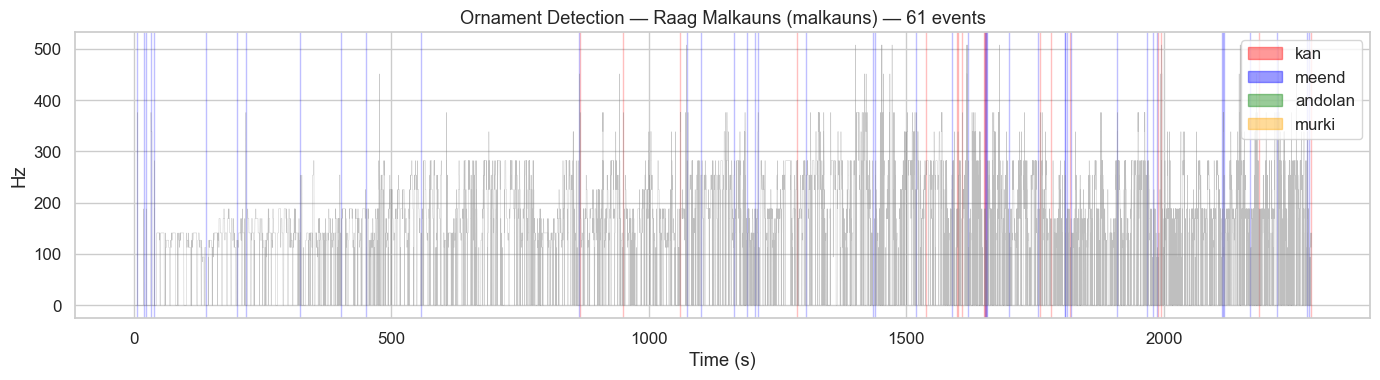

In [31]:
# Cell 7 — Visualization: Ornament Detection on Sample Track

# Pick a track with many ornaments for visualization
viz_key = max(track_results, key=lambda k: len(track_results[k]["events"]))
viz_trk = loaded_tracks[viz_key]
viz_pp = preprocessed[viz_key]
viz_res = track_results[viz_key]

color_map = {"kan": "red", "meend": "blue", "andolan": "green", "murki": "orange"}
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(viz_trk.f0_times, viz_pp["quant_hz"], lw=0.3, color="grey", alpha=0.5)
for ev in viz_res["events"]:
    c = color_map.get(ev.label, "black")
    ax.axvspan(ev.start_time, ev.end_time, alpha=0.25, color=c)
ax.set_xlabel("Time (s)"); ax.set_ylabel("Hz")
ax.set_title(f"Ornament Detection — {viz_key[1]} ({viz_trk.raga}) — {len(viz_res['events'])} events")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, alpha=0.4, label=l) for l, c in color_map.items()], loc="upper right")
plt.tight_layout(); plt.show()

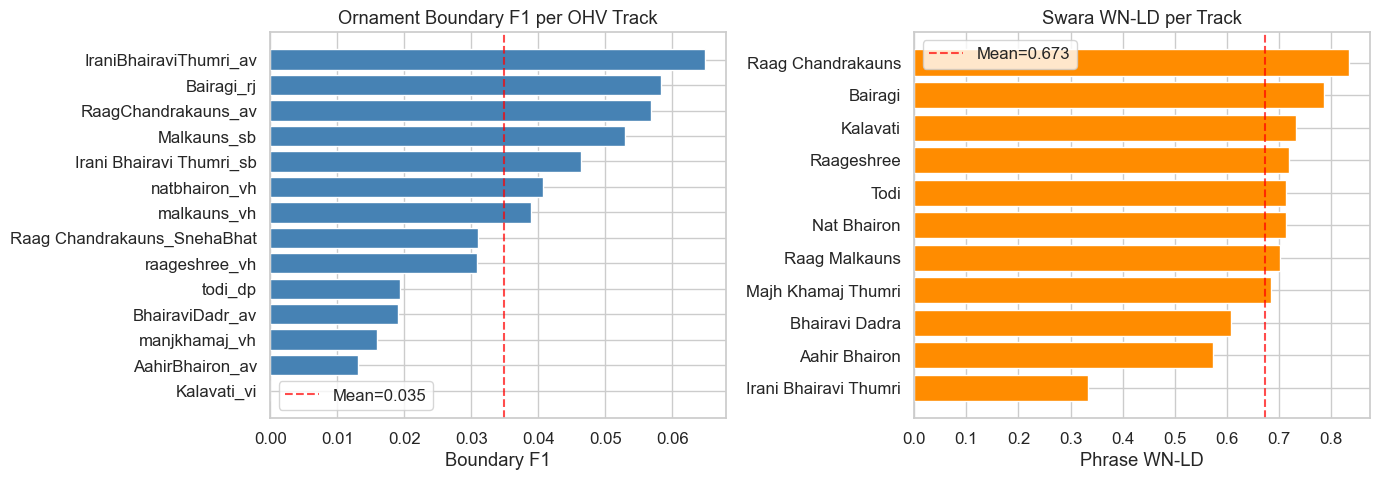

In [32]:
# Cell 8 — Per-Raga Boundary F1 Bar Chart

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boundary F1 per OHV track
bhr_sorted = bhr_df.sort_values("f1", ascending=True)
axes[0].barh(bhr_sorted["ohv_track"], bhr_sorted["f1"], color="steelblue")
axes[0].set_xlabel("Boundary F1"); axes[0].set_title("Ornament Boundary F1 per OHV Track")
axes[0].axvline(bhr_df["f1"].mean(), color="red", linestyle="--", alpha=0.7, label=f"Mean={bhr_df['f1'].mean():.3f}")
axes[0].legend()

# Swara WN-LD per track
if len(swara_df) > 0:
    sw_sorted = swara_df.sort_values("phrase_wnld", ascending=True)
    axes[1].barh(sw_sorted["track"], sw_sorted["phrase_wnld"], color="darkorange")
    axes[1].set_xlabel("Phrase WN-LD"); axes[1].set_title("Swara WN-LD per Track")
    axes[1].axvline(swara_df["phrase_wnld"].mean(), color="red", linestyle="--", alpha=0.7,
                    label=f"Mean={swara_df['phrase_wnld'].mean():.3f}")
    axes[1].legend()

plt.tight_layout(); plt.show()

In [33]:
# Cell 9 — Summary

print("=" * 70)
print("MULTI-RAGA EVALUATION SUMMARY")
print("=" * 70)
print(f"OHV annotation files evaluated:  {len(OHV_SARAGA_MAP)}")
print(f"Unique Saraga tracks processed:  {len(loaded_tracks)}")
print()
total_events = sum(len(r["events"]) for r in track_results.values())
total_phrases = sum(len(r["phrases"]) for r in track_results.values())
print(f"Total phrases detected:   {total_phrases}")
print(f"Total ornament events:    {total_events}")
print()
print("--- Ornament Boundary Evaluation ---")
print(f"  Mean Precision: {bhr_df['precision'].mean():.4f}")
print(f"  Mean Recall:    {bhr_df['recall'].mean():.4f}")
print(f"  Mean F1:        {bhr_df['f1'].mean():.4f}")
print()
if len(swara_df) > 0:
    print("--- Swara Transcription ---")
    print(f"  Mean Phrase WN-LD: {swara_df['phrase_wnld'].mean():.4f} ± {swara_df['phrase_wnld'].std():.4f}")
    print(f"  Mean File WN-LD:   {swara_df['file_wnld'].mean():.4f}")
    print()
    print("--- Best / Worst tracks (Phrase WN-LD) ---")
    best = swara_df.loc[swara_df["phrase_wnld"].idxmax()]
    worst = swara_df.loc[swara_df["phrase_wnld"].idxmin()]
    print(f"  Best:  {best['track']} ({best['raga']}) = {best['phrase_wnld']:.4f}")
    print(f"  Worst: {worst['track']} ({worst['raga']}) = {worst['phrase_wnld']:.4f}")
print("=" * 70)

MULTI-RAGA EVALUATION SUMMARY
OHV annotation files evaluated:  14
Unique Saraga tracks processed:  11

Total phrases detected:   1029
Total ornament events:    126

--- Ornament Boundary Evaluation ---
  Mean Precision: 0.2971
  Mean Recall:    0.0203
  Mean F1:        0.0349

--- Swara Transcription ---
  Mean Phrase WN-LD: 0.6726 ± 0.1334
  Mean File WN-LD:   0.6915

--- Best / Worst tracks (Phrase WN-LD) ---
  Best:  Raag Chandrakauns (chandrakauns) = 0.8333
  Worst: Irani Bhairavi Thumri (irani_bhairavi) = 0.3333
